In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #cbcaf0; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #04335a">Stokes Equations on an Exchanger Device</h3>
</div>

Imports:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from Solvers.Exchanger_Device import compute_U_P_solution_exchanger_device

from Utilities.Mesh_processing import (
    refine
)

from Utilities.Plot_functions import (
    Plot_Initial_Refined_meshes,
    Plot_Velocity_and_Pressure
)

---

### Inlet profile exploration:
This code defines a quadratic profile function and identifies mesh boundary nodes corresponding to the inlet, outlet, and solid walls based on spatial coordinate extrema. It isolates wall and inlet nodes to assemble the complete set of Dirichlet boundary nodes required for the numerical simulation. Finally, it initializes velocity vectors and prescribes a parabolic flow profile across the horizontal inlet boundary.

---

Mesh:

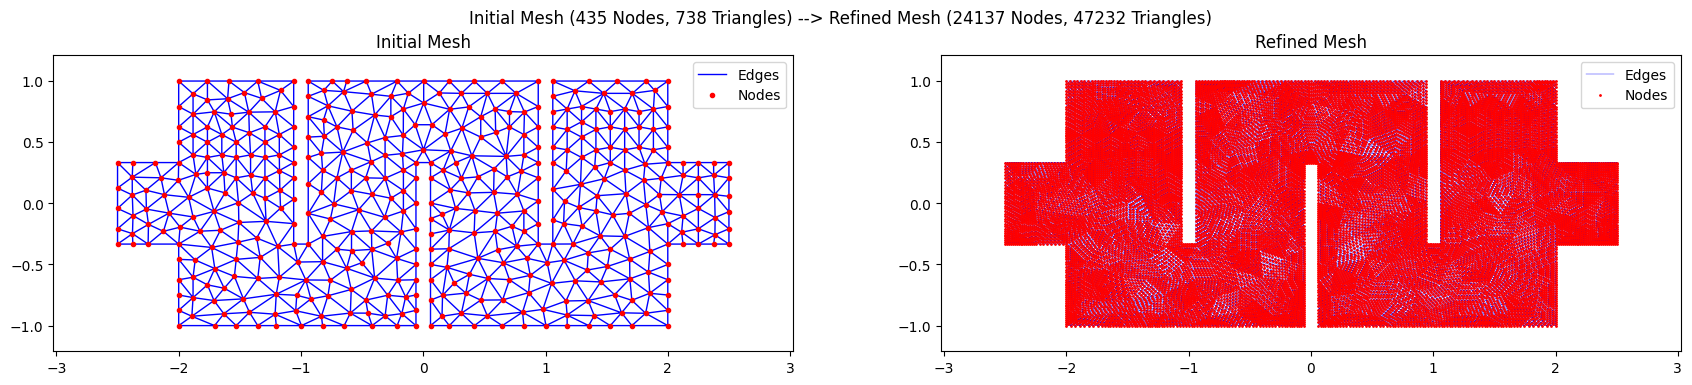

In [3]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(
    data_path='Meshes/exchanger_device_altered_mesh_data.npz',
    num_of_refinements=3,
    figsize=(21, 4),
    plot=True
)
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

Inlet profile:

In [4]:
def parabolic_inlet_profile(x, x_1, x_2, alpha):
    return -alpha*(x - x_1)*(x - x_2)

Nv = p_fine.shape[0]
Np = p_coarse.shape[0]
eps = 1e-10   

xmin = p_fine[:, 0].min()
xmax = p_fine[:, 0].max()

inlet_idx  = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]
outlet_idx = np.where(np.abs(p_fine[:, 0] - xmax) < eps)[0]

corner_idx  = [inlet_idx[np.argmax(p_fine[inlet_idx, 1])], 
               inlet_idx[np.argmin(p_fine[inlet_idx, 1])]]

boundary_nodes = np.unique(e_fine[e_fine[:, 2] > 0, 0:2])
v_wall_idx = np.setdiff1d(boundary_nodes, np.concatenate([inlet_idx, outlet_idx]))
dirichlet_nodes = np.unique(np.concatenate([inlet_idx, v_wall_idx]))

lf_x = np.zeros(Nv)
lf_y = np.zeros(Nv)

y_inlet = p_fine[inlet_idx, 1]
y_top, y_bottom = p_fine[corner_idx[0], 1], p_fine[corner_idx[1], 1]
lf_x[inlet_idx] = parabolic_inlet_profile(y_inlet, y_top, y_bottom, alpha=3)

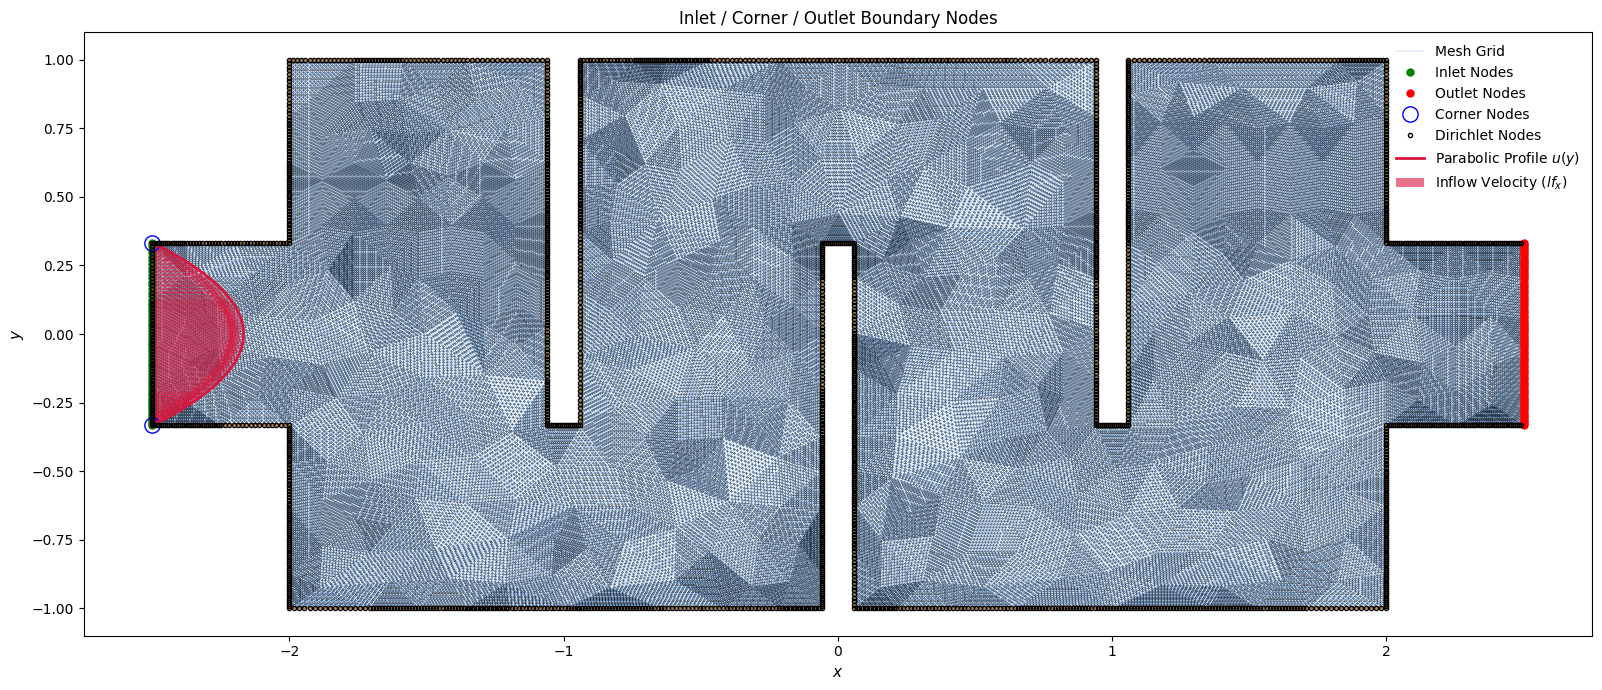

In [5]:
fig, ax = plt.subplots(figsize=(21, 7))

ax.triplot(p_fine[:, 0], p_fine[:, 1], t_fine[:, :3], color='#4A90E2', lw=0.3, alpha=0.7, label='Mesh Grid')
ax.plot(p_fine[:, 0], p_fine[:, 1], 'o', color='k', markersize=0.3, alpha=1)
ax.plot(p_fine[inlet_idx, 0],  p_fine[inlet_idx, 1],  'go', markersize=5, zorder=5, label='Inlet Nodes')
ax.plot(p_fine[outlet_idx, 0], p_fine[outlet_idx, 1], 'ro', markersize=5, zorder=5, label='Outlet Nodes')
ax.plot(p_fine[corner_idx, 0], p_fine[corner_idx, 1], 'bo', markersize=11, zorder=7, markerfacecolor='none', label='Corner Nodes')
ax.plot(p_fine[dirichlet_nodes, 0], p_fine[dirichlet_nodes, 1], 'ko', markersize=3, zorder=10, markerfacecolor='none', label='Dirichlet Nodes')

sort_perm = np.argsort(y_inlet)
ax.plot(xmin + lf_x[inlet_idx][sort_perm], y_inlet[sort_perm], color='crimson', lw=2, zorder=8, label='Parabolic Profile $u(y)$')
ax.quiver(p_fine[inlet_idx, 0], y_inlet, lf_x[inlet_idx], np.zeros_like(y_inlet), angles='xy', scale_units='xy', scale=1, color='crimson', alpha=0.6, width=0.002, zorder=6, label=r'Inflow Velocity ($lf_x$)')

flag1_mask = (e_coarse[:, -1] == 1)
boundary_edges = e_coarse[flag1_mask, :2].astype(int)
x_coords = p_coarse[boundary_edges, 0].T
y_coords = p_coarse[boundary_edges, 1].T

ax.plot(x_coords, y_coords, color="#FF9100", linewidth=1.5, alpha = 0.5)

ax.set_aspect('equal')
ax.set_xlabel('$x$', fontsize=11)
ax.set_ylabel('$y$', fontsize=11)
ax.set_title('Inlet / Corner / Outlet Boundary Nodes', fontsize=12)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
ax.grid(False)

plt.tight_layout()
plt.savefig("Outputs/Conditioning_Inlet.png", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

In [6]:
ux, uy, p_sol = compute_U_P_solution_exchanger_device(p_fine, t_fine, e_fine, p_coarse, t_coarse)

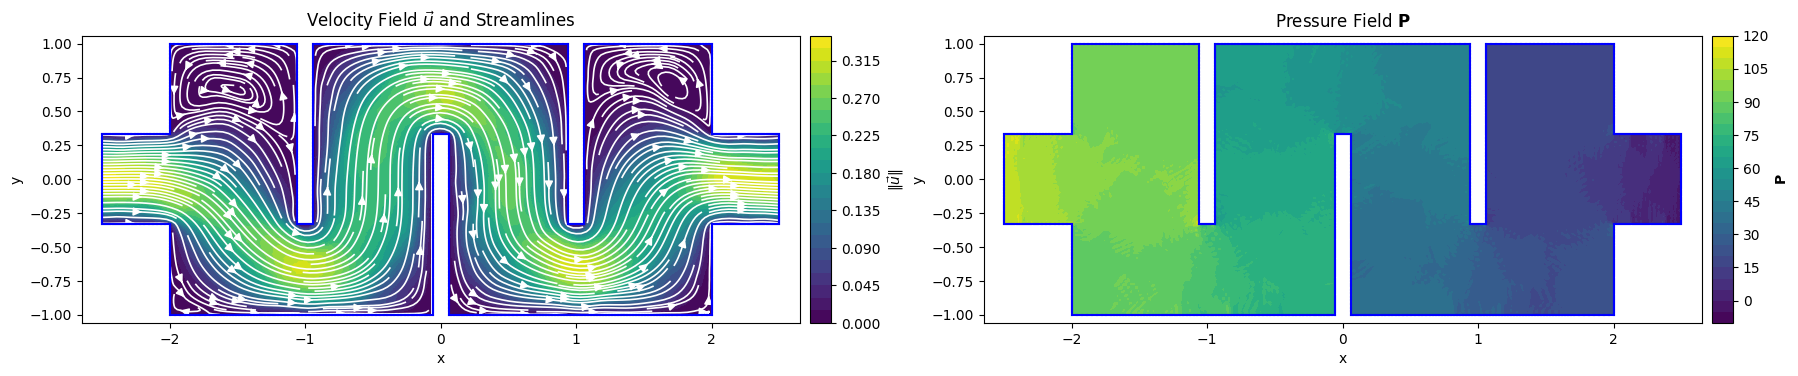

In [7]:
Plot_Velocity_and_Pressure(p_fine, t_fine, p_coarse, t_coarse, e_coarse, ux, uy, p_sol)

---